In [1]:
import os
import numpy as np
import pandas as pd
from konlpy.tag import Okt
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

 

In [2]:
# ============================================================
# 경로 및 파일 설정
# ============================================================
data_dir = 'data/synopsis'
 
genre_txt = [
    'synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt',
    'synopsis_horror.txt', 'synopsis_etc.txt', 'synopsis_documentary.txt',
    'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
    'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt',
    'synopsis_western.txt', 'synopsis_adult.txt', 'synopsis_thriller.txt',
    'synopsis_animation.txt', 'synopsis_action.txt', 'synopsis_adventure.txt',
    'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt'
]
 
genre_name = [
    'SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마',
    '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
    '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지'
]
 

In [3]:
# ============================================================
# 1. 텍스트 토크나이징 (명사 추출)
# ============================================================
def read_token(file_name):
    okt = Okt()
    result = []
    file_path = os.path.join(data_dir, file_name)
    with open(file_path, 'r', encoding='utf-8') as fread:
        while True:
            line = fread.readline()
            if not line:
                break
            nouns = [word for word in okt.nouns(line) if len(word) > 1]
            result.extend(nouns)
    return ' '.join(result)
 
print("=" * 60)
print("  STEP 1: 데이터 로딩 및 형태소 분석 중...")
print("=" * 60)
art_str = read_token('synopsis_art.txt')
gen_str = read_token('synopsis_gen.txt')
genre_contents = [read_token(txt) for txt in genre_txt]
print("✅ 데이터 로딩 완료.\n")

  STEP 1: 데이터 로딩 및 형태소 분석 중...
✅ 데이터 로딩 완료.



In [4]:
# ============================================================
# 2. Word2Vec 학습 (Skip-gram)
# ============================================================
print("=" * 60)
print("  STEP 2: Word2Vec 학습 시작 (Skip-gram)...")
print("=" * 60)
all_docs = [art_str, gen_str] + genre_contents
sentences = [doc.split() for doc in all_docs if doc]
model = Word2Vec(sentences, vector_size=100, window=5, min_count=3, sg=1, workers=4, epochs=10)
print(f"✅ 모델 학습 완료. 어휘 크기: {len(model.wv)} 단어\n")
 
# 임베딩 품질 확인
print("[임베딩 품질 확인 - most_similar 예시]")
test_words = ['사랑', '전쟁', '범죄', '공포', '우주']
for w in test_words:
    if w in model.wv:
        similars = model.wv.most_similar(w, topn=5)
        print(f"  '{w}' 유사 단어: {[x[0] for x in similars]}")
print()
 

  STEP 2: Word2Vec 학습 시작 (Skip-gram)...
✅ 모델 학습 완료. 어휘 크기: 29049 단어

[임베딩 품질 확인 - most_similar 예시]
  '사랑' 유사 단어: ['연인', '재회', '만남', '이사벨', '이별']
  '전쟁' 유사 단어: ['시기', '세계대전', '소용돌이', '폐허', '직후']
  '범죄' 유사 단어: ['검거', '모방', '마피아', '갱단', '라임']
  '공포' 유사 단어: ['극도', '악몽', '환영', '두려움', '실체']
  '우주' 유사 단어: ['행성', '멸망', '인류', '온난화', '기후']



In [5]:
# ============================================================
# 3. 대표 단어 셋 추출 (TF-IDF 기반, 중복 제거)
# ============================================================
print("=" * 60)
print("  STEP 3: 대표 단어 셋 추출 (TF-IDF + 중복 제거)")
print("=" * 60)
 
N_WORDS = 30  # 축당 대표 단어 수

  STEP 3: 대표 단어 셋 추출 (TF-IDF + 중복 제거)


In [6]:
# ----------------------------------------------------------
# 3-1. Attribute (예술/일반) 대표 단어 - TF-IDF 차이 기반
# ----------------------------------------------------------
vectorizer_attr = TfidfVectorizer(max_features=5000)
X_attr = vectorizer_attr.fit_transform([art_str, gen_str])
vocab_attr = vectorizer_attr.get_feature_names_out()
score_diff = X_attr[0].toarray().flatten() - X_attr[1].toarray().flatten()
sorted_idx = np.argsort(score_diff)
 
# 모델에 존재하는 단어만, 상위 N_WORDS 추출
target_art = [vocab_attr[i] for i in reversed(sorted_idx) if vocab_attr[i] in model.wv][:N_WORDS]
target_gen = [vocab_attr[i] for i in sorted_idx       if vocab_attr[i] in model.wv][:N_WORDS]
 
# art, gen 간 중복 제거
art_set = set(target_art)
gen_set = set(target_gen)
overlap = art_set & gen_set
target_art = [w for w in target_art if w not in overlap][:N_WORDS]
target_gen = [w for w in target_gen if w not in overlap][:N_WORDS]
 
print(f"▶ 예술 영화 대표 단어 ({len(target_art)}개): {target_art[:15]}...")
print(f"▶ 일반 영화 대표 단어 ({len(target_gen)}개): {target_gen[:15]}...\n")
 

▶ 예술 영화 대표 단어 (30개): ['사랑', '시작', '과연', '세상', '마을', '마음', '인생', '위해', '가족', '음악', '아빠', '사람', '모든', '서로', '파리']...
▶ 일반 영화 대표 단어 (30개): ['영화제', '국제', '서울', '애니메이션', '작품', '단편', '남편', '연출', '의도', '부문', '여성', '관계', '섹스', '생각', '부천']...



In [7]:
# ----------------------------------------------------------
# 3-2. 장르별 대표 단어 - TF-IDF 기반 (장르 특이성 반영)
# ----------------------------------------------------------
# 전체 장르 문서로 TF-IDF 계산 → 각 장르의 특징 단어 추출
vectorizer_genre = TfidfVectorizer(max_features=10000)
X_genre = vectorizer_genre.fit_transform(genre_contents)
vocab_genre = vectorizer_genre.get_feature_names_out()
 
# attribute 단어 집합 (장르 단어와 중복 방지)
attr_words = set(target_art) | set(target_gen)
 
genre_top_words = []
print("[장르별 대표 단어 추출 결과]")
print("-" * 60)
for i, name in enumerate(genre_name):
    # 해당 장르의 TF-IDF 점수 기준 정렬
    tfidf_scores = X_genre[i].toarray().flatten()
    sorted_genre_idx = np.argsort(tfidf_scores)[::-1]
 
    valid_words = []
    seen = set()
    for idx in sorted_genre_idx:
        w = vocab_genre[idx]
        # 조건: 모델에 존재 + 중복 없음 + attribute 단어와 겹치지 않음 + 길이 2자 이상
        if w in model.wv and w not in seen and w not in attr_words and len(w) >= 2:
            valid_words.append(w)
            seen.add(w)
        if len(valid_words) >= N_WORDS:
            break
 
    genre_top_words.append(valid_words)
    print(f"  🎬 {name:12}: {', '.join(valid_words[:10])}...")
 
print()
 

[장르별 대표 단어 추출 결과]
------------------------------------------------------------
  🎬 SF          : 자신, 지구, 인류, 인간, 미래, 우주, 로봇, 세계, 박사, 우주선...
  🎬 가족          : 자신, 친구, 아주르, 아버지, 아들, 낙타, 할머니, 동구, 아이, 학교...
  🎬 공연          : 오페라, 토스카, 실황, 올레, 자신, 카바, 공연, 오텔로, 리골레토, 백작...
  🎬 공포(호러)      : 자신, 친구, 사건, 공포, 발견, 죽음, 악령, 남자, 좀비, 사실...
  🎬 기타          : 자신, 남자, 뉴미디어, 여자, 친구, 아시아나, 다른, 우리, 아이, 시간...
  🎬 다큐멘터리       : 다큐멘터리, 자신, 감독, 우리, 세계, 한국, 사회, 아이, 노동자, 가장...
  🎬 드라마         : 자신, 남자, 친구, 여자, 아버지, 아들, 아이, 시간, 감독, 다른...
  🎬 멜로로맨스       : 자신, 남자, 여자, 친구, 결혼, 아내, 부부, 아버지, 사실, 다시...
  🎬 뮤지컬         : 뮤지컬, 에스메랄다, 충무로, 모차르트, 토스카, 자신, 카바, 바흐, 모도, 카르피...
  🎬 미스터리        : 사건, 자신, 발견, 사고, 진실, 죽음, 기억, 살인, 친구, 아내...
  🎬 범죄          : 사건, 자신, 경찰, 범죄, 조직, 살인, 마약, 형사, 남자, 살해...
  🎬 사극          : 조선, 자신, 황제, 운명, 최고, 전쟁, 윤서, 트로이, 권력, 아킬레스...
  🎬 서부극(웨스턴)    : 서부, 보안관, 카우보이, 헨리, 자신, 아이, 무법자, 프린트, 현상금, 분노...
  🎬 성인물(에로)     : 마사지, 자신, 정사, 남자, 여자, 유부녀, 에피소드, 그린, 아내, 다시...
  🎬 스릴러         : 자신, 사건, 살인, 남자, 발견, 아내

In [8]:
# ============================================================
# 4. WEAT Score 계산
# ============================================================
print("=" * 60)
print("  STEP 4: WEAT Score 계산")
print("=" * 60)
 
def cosine_sim(w_vec, target_vecs):
    """단어 벡터와 타겟 벡터들의 평균 코사인 유사도"""
    w_vec = w_vec.reshape(1, -1)
    return np.mean(cosine_similarity(w_vec, target_vecs))
 
def s_word(w, A, B):
    """단어 w의 A vs B 연관 차이 (WEAT s 함수)"""
    w_vec = model.wv[w]
    A_vecs = np.array([model.wv[a] for a in A if a in model.wv])
    B_vecs = np.array([model.wv[b] for b in B if b in model.wv])
    return cosine_sim(w_vec, A_vecs) - cosine_sim(w_vec, B_vecs)
 
def weat_score(X_words, A_words, B_words):
    """장르 X에 대한 A(예술) vs B(일반) WEAT score"""
    X_valid = [w for w in X_words if w in model.wv]
    if not X_valid:
        return np.nan
    scores = [s_word(w, A_words, B_words) for w in X_valid]
    return np.mean(scores)
 

  STEP 4: WEAT Score 계산


In [9]:
# ----------------------------------------------------------
# 4-1. 예술(art) vs 일반(gen): 21개 장르 WEAT
# ----------------------------------------------------------
weat_art_gen = []
for i, name in enumerate(genre_name):
    score = weat_score(genre_top_words[i], target_art, target_gen)
    weat_art_gen.append((name, score))
 
df_art_gen = pd.DataFrame(weat_art_gen, columns=['Genre', 'Score_Art_vs_Gen'])
df_art_gen = df_art_gen.sort_values('Score_Art_vs_Gen', ascending=False).reset_index(drop=True)
print("▶ 예술 vs 일반 WEAT Score (상위 순):")
print(df_art_gen.to_string(index=False))
print()

▶ 예술 vs 일반 WEAT Score (상위 순):
   Genre  Score_Art_vs_Gen
      범죄          0.026146
      액션          0.025265
  공포(호러)          0.020840
      전쟁          0.018704
서부극(웨스턴)          0.016495
     판타지          0.012685
     스릴러          0.008501
    어드벤처          0.007902
      사극          0.005526
      공연          0.005228
    미스터리          0.003243
      가족          0.000553
     코미디         -0.006224
   멜로로맨스         -0.007308
      SF         -0.008706
     드라마         -0.009824
     뮤지컬         -0.021009
 성인물(에로)         -0.022975
   애니메이션         -0.036066
      기타         -0.076335
   다큐멘터리         -0.083529



In [10]:
# ----------------------------------------------------------
# 4-2. 21 × 21 장르 간 WEAT 매트릭스
# ============================================================
# 각 셀 (i, j): 장르 i의 단어들이 장르 j vs 나머지 장르에 얼마나 편향되어 있는가
# → 장르 i 단어 기준, (장르 j 단어 vs 장르 j 제외 전체 단어) WEAT
# ----------------------------------------------------------
print("=" * 60)
print("  STEP 5: 21×21 장르 간 WEAT 매트릭스 계산")
print("=" * 60)
 
n = len(genre_name)
weat_matrix = np.zeros((n, n))
 
for i in range(n):
    for j in range(n):
        if i == j:
            # 자기 자신: 자기 단어 vs 나머지 전체 평균 (장르 자기 편향)
            other_words = []
            for k in range(n):
                if k != i:
                    other_words.extend(genre_top_words[k])
            score = weat_score(genre_top_words[i], genre_top_words[i], other_words)
        else:
            # i 행 장르 단어가 j열 장르 vs 나머지에 얼마나 치우쳐 있나
            other_words = []
            for k in range(n):
                if k != j:
                    other_words.extend(genre_top_words[k])
            score = weat_score(genre_top_words[i], genre_top_words[j], other_words)
        weat_matrix[i][j] = score if not np.isnan(score) else 0.0
 
    print(f"  진행 중: {genre_name[i]} ({i+1}/{n})")
 
df_matrix = pd.DataFrame(weat_matrix, index=genre_name, columns=genre_name)
print("\n✅ 21×21 WEAT 매트릭스 계산 완료.\n")

  STEP 5: 21×21 장르 간 WEAT 매트릭스 계산
  진행 중: SF (1/21)
  진행 중: 가족 (2/21)
  진행 중: 공연 (3/21)
  진행 중: 공포(호러) (4/21)
  진행 중: 기타 (5/21)
  진행 중: 다큐멘터리 (6/21)
  진행 중: 드라마 (7/21)
  진행 중: 멜로로맨스 (8/21)
  진행 중: 뮤지컬 (9/21)
  진행 중: 미스터리 (10/21)
  진행 중: 범죄 (11/21)
  진행 중: 사극 (12/21)
  진행 중: 서부극(웨스턴) (13/21)
  진행 중: 성인물(에로) (14/21)
  진행 중: 스릴러 (15/21)
  진행 중: 애니메이션 (16/21)
  진행 중: 액션 (17/21)
  진행 중: 어드벤처 (18/21)
  진행 중: 전쟁 (19/21)
  진행 중: 코미디 (20/21)
  진행 중: 판타지 (21/21)

✅ 21×21 WEAT 매트릭스 계산 완료.



In [11]:
# ============================================================
# 5. 시각화
# ============================================================
print("=" * 60)
print("  STEP 6: 시각화")
print("=" * 60)
 
# 한국어 폰트 설정
def set_korean_font():
    candidates = [
        'NanumGothic', 'NanumBarunGothic', 'Malgun Gothic',
        'AppleGothic', 'UnDotum', 'DejaVu Sans'
    ]
    available = [f.name for f in fm.fontManager.ttflist]
    for font in candidates:
        if font in available:
            plt.rcParams['font.family'] = font
            return font
    # 폰트 없으면 영문 레이블 사용
    return None
 
korean_font = set_korean_font()
plt.rcParams['axes.unicode_minus'] = False

  STEP 6: 시각화


✅ 예술/일반 막대 그래프 저장: weat_art_gen_bar.png


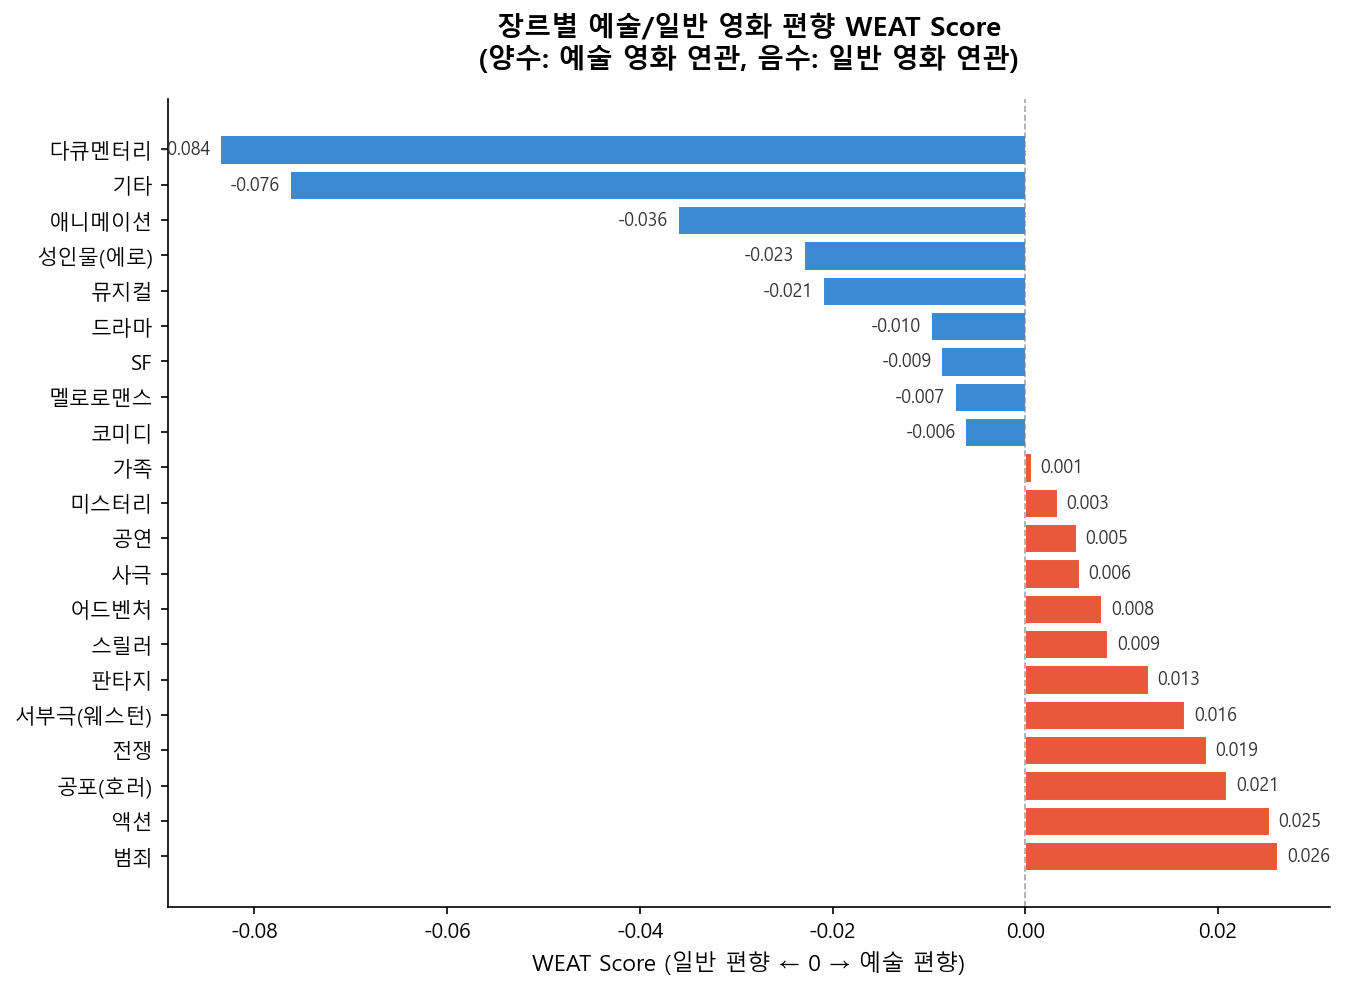

In [17]:
# ----------------------------------------------------------
# 5-1. 예술 vs 일반 WEAT 막대 그래프
# ----------------------------------------------------------
from IPython.display import display, Image

fig1, ax1 = plt.subplots(figsize=(10, 7))
 
df_sorted = df_art_gen.copy()
colors = ['#E8593C' if s > 0 else '#3B8BD4' for s in df_sorted['Score_Art_vs_Gen']]
 
bars = ax1.barh(df_sorted['Genre'], df_sorted['Score_Art_vs_Gen'],
                color=colors, edgecolor='white', linewidth=0.5)
 
ax1.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
ax1.set_xlabel('WEAT Score (일반 편향 ← 0 → 예술 편향)', fontsize=11)
ax1.set_title('장르별 예술/일반 영화 편향 WEAT Score\n(양수: 예술 영화 연관, 음수: 일반 영화 연관)',
              fontsize=13, fontweight='bold', pad=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
 
# 값 레이블
for bar, val in zip(bars, df_sorted['Score_Art_vs_Gen']):
    ax1.text(val + (0.001 if val >= 0 else -0.001),
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}',
             va='center', ha='left' if val >= 0 else 'right',
             fontsize=8.5, color='#333333')
 
# 이미지 파일로 저장
output_filename = 'weat_art_gen_bar.png'
plt.savefig(output_filename, dpi=150, bbox_inches='tight')
plt.close() # 그래프 생성에 사용된 자원 해제

print(f"✅ 예술/일반 막대 그래프 저장: {output_filename}")

# 파일을 다시 읽어서 출력합니다.
display(Image(filename=output_filename))

✅ 21×21 히트맵 저장: weat_21x21_heatmap.png


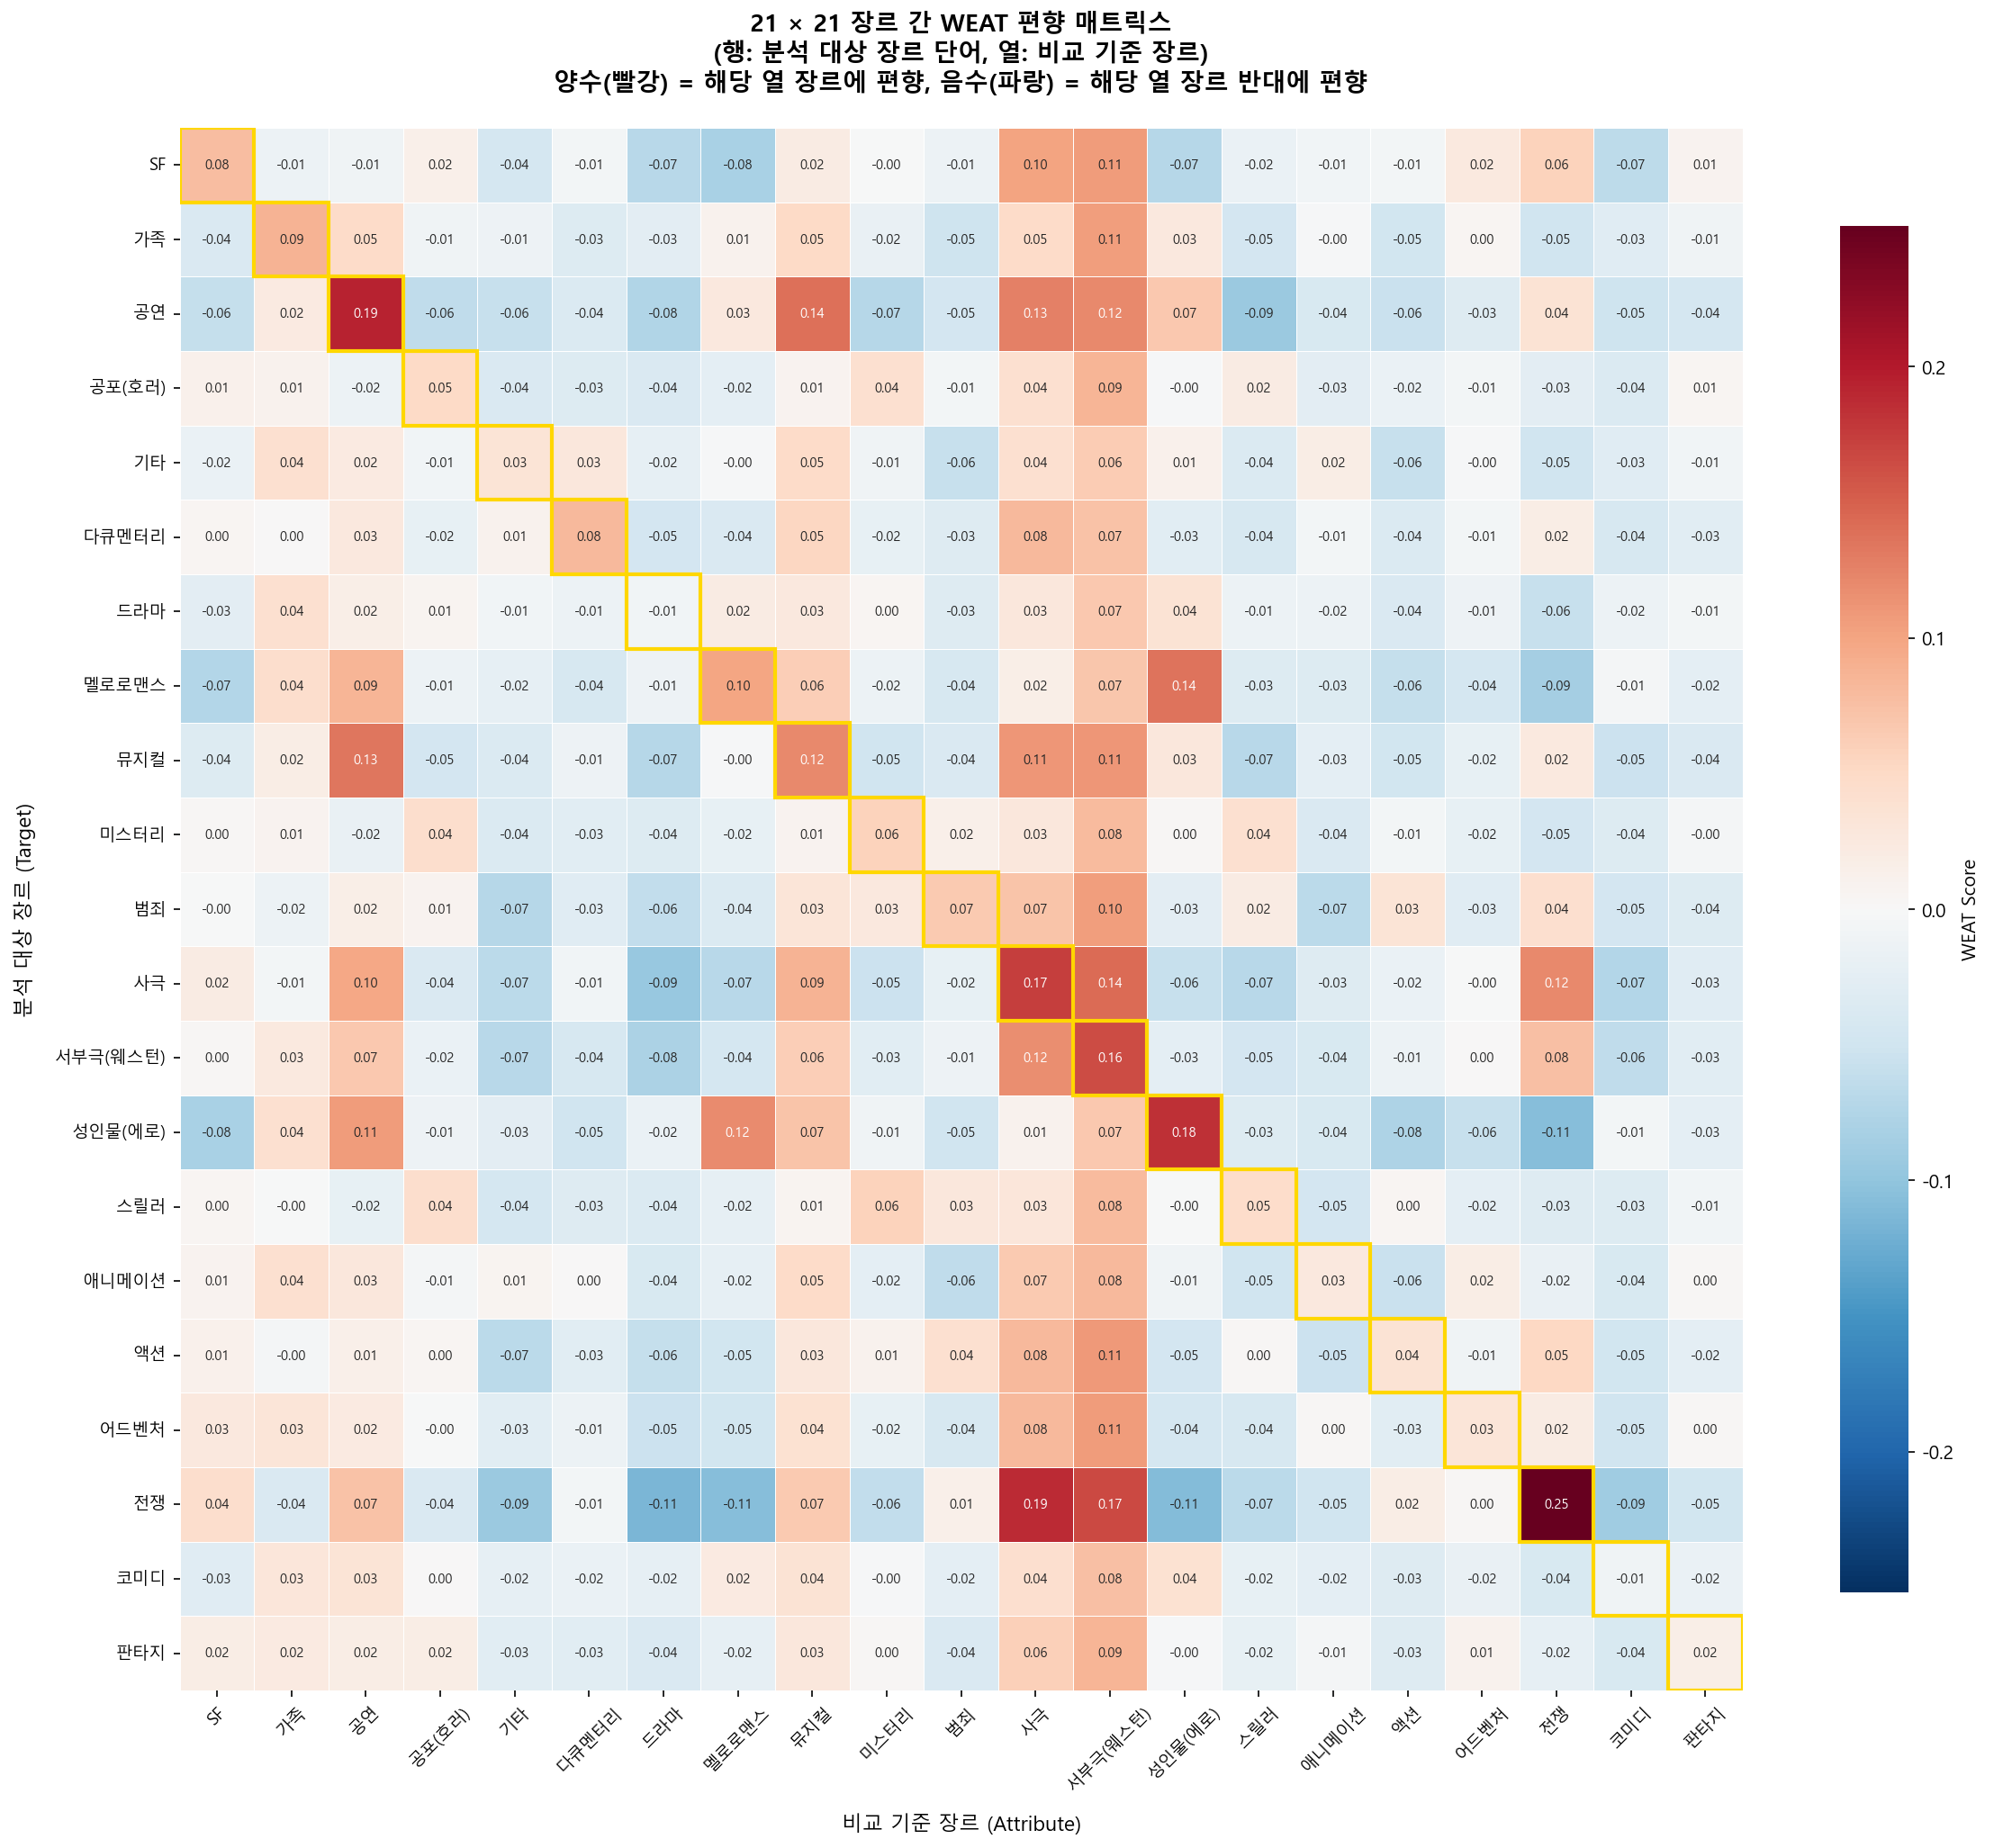

In [18]:
# ----------------------------------------------------------
# 5-2. 21 × 21 히트맵
# ----------------------------------------------------------

fig2, ax2 = plt.subplots(figsize=(16, 14))

# 데이터 프레임과 매트릭스가 정의되어 있어야 합니다. (df_matrix, weat_matrix)
vmax = np.abs(weat_matrix).max()
vmin = -vmax

sns.heatmap(
    df_matrix,
    ax=ax2,
    cmap='RdBu_r',        # 빨강(양수/예술 편향) ↔ 파랑(음수/일반 편향)
    center=0,
    vmin=vmin,
    vmax=vmax,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.3,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'WEAT Score', 'shrink': 0.8}
)

ax2.set_title('21 × 21 장르 간 WEAT 편향 매트릭스\n'
              '(행: 분석 대상 장르 단어, 열: 비교 기준 장르)\n'
              '양수(빨강) = 해당 열 장르에 편향, 음수(파랑) = 해당 열 장르 반대에 편향',
              fontsize=13, fontweight='bold', pad=20)

ax2.set_xlabel('비교 기준 장르 (Attribute)', fontsize=11, labelpad=10)
ax2.set_ylabel('분석 대상 장르 (Target)', fontsize=11, labelpad=10)

ax2.tick_params(axis='x', rotation=45, labelsize=9)
ax2.tick_params(axis='y', rotation=0,  labelsize=9)

# 대각선 강조 (자기 편향) - n은 genre_name의 길이
n = len(df_matrix)
for i in range(n):
    ax2.add_patch(plt.Rectangle((i, i), 1, 1,
                                fill=False, edgecolor='gold',
                                lw=2, clip_on=True))

plt.tight_layout()

# 이미지 파일 저장
heatmap_filename = 'weat_21x21_heatmap.png'
plt.savefig(heatmap_filename, dpi=150, bbox_inches='tight')
plt.close()

print(f"✅ 21×21 히트맵 저장: {heatmap_filename}")

# --- [추가] 저장된 히트맵 이미지를 화면에 출력 ---
display(Image(filename=heatmap_filename))

In [19]:
# ----------------------------------------------------------
# 5-3. 결과 CSV 저장
# ----------------------------------------------------------
df_matrix.to_csv('weat_matrix.csv', encoding='utf-8-sig')
df_art_gen.to_csv('weat_art_gen.csv', encoding='utf-8-sig', index=False)
 
print("\n" + "=" * 60)
print("  모든 결과 저장 완료!")
print("  - weat_art_gen_bar.png  : 예술/일반 편향 막대 그래프")
print("  - weat_21x21_heatmap.png: 21×21 장르 간 WEAT 히트맵")
print("  - weat_matrix.csv       : 21×21 매트릭스 데이터")
print("  - weat_art_gen.csv      : 예술/일반 WEAT 점수 데이터")
print("=" * 60)


  모든 결과 저장 완료!
  - weat_art_gen_bar.png  : 예술/일반 편향 막대 그래프
  - weat_21x21_heatmap.png: 21×21 장르 간 WEAT 히트맵
  - weat_matrix.csv       : 21×21 매트릭스 데이터
  - weat_art_gen.csv      : 예술/일반 WEAT 점수 데이터


# 워드 임베딩을 이용한 영화 장르별 예술성 및 장르 간 편향성 분석

## 1. 실험 개요
* **목적**: 본 분석은 영화 시놉시스 코퍼스(Corpus)를 바탕으로 학습된 단어 임베딩 모델을 사용하여, 특정 영화 장르가 '예술 영화' 혹은 '일반 영화' 중 어느 쪽에 더 강한 연관성을 갖는지, 그리고 각 장르 간에는 어떤 상대적 편향성을 보이는지 수치적으로 검증하는 것을 목적으로 합니다.

---

## 2. 실험 설계 및 Flowchart

독립 변수: 21개 영화 장르별 시놉시스 텍스트 데이터.  
종속 변수: WEAT Score (Target 단어 셋과 Attribute 단어 셋 간의 상대적 코사인 유사도 차이).  

통제 요인:
  
  동일한 형태소 분석기(Okt) 및 추출 조건(명사, 2자 이상).  
  동일한 Word2Vec 하이퍼파라미터 (Skip-gram, Vector size 100).  
  TF-IDF를 통한 상위 30개 단어 추출 방식 통일.

![flowchart1](img/weat_pipeline_step1_data.svg)  
![flowchart2](img/weat_pipeline_step2_wordsets.svg)  
![flowchart3](img/weat_pipeline_step3_score.svg)  
---



## 3. 결론 및 회고

영화 시놉시스 데이터에 내재된 장르별 의미론적 편향성을 정량적으로 확인하였습니다.  

단순 빈도수 기반으로 대표 단어를 뽑았을 때보다 TF-IDF를 적용했을 때 장르의 개성이 훨씬 뚜렷하게 반영되었습니다.  

결과값이 $-0.02 \sim 0.12$ 수준으로 작게 나온 것은 데이터셋 내에서 장르 간 단어 사용의 경계가 아주 엄격하지 않는것 같습니다.  